# Module 1 — Baseline Cooperation Rates

**Research Question**: How cooperative are different LLMs in the repeated Prisoner's Dilemma?

**Outputs**: Table 1 (cooperation rates), Figure 1 (heatmap), Figure 1b (personality effect)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# ── Publication-quality settings ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False,
})

# ── Color palette (color-blind friendly) ──
MODEL_COLORS = {
    'gpt-oss-20b': '#E69F00',
    'Mistral-7B-Instruct-v0.3': '#56B4E9',
    'Qwen2.5-32B-Instruct': '#009E73'
}
MODEL_LABELS = {
    'gpt-oss-20b': 'GPT-oss-20B',
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen2.5-32B'
}
NOISE_LABELS = {0.0: 'No Noise', 0.05: '5% Noise', 0.2: '20% Noise'}

FIGURE_DIR = 'figures/'
import os
os.makedirs(FIGURE_DIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── Load data ──
DATA_PATH = '../resources/results/Prisoner_dilemma_2player/consolidated_dataset.csv'
df = pd.read_csv(DATA_PATH)

# Normalize personality to English
PERSONALITY_MAP = {
    'cooperative': 'Cooperative', 'selfish': 'Selfish',
    'coopératif': 'Cooperative', 'égoïste': 'Selfish',
    'متعاون': 'Cooperative', 'أناني': 'Selfish',
    '合作型的': 'Cooperative', '自私型的': 'Selfish',
    'một người hợp tác': 'Cooperative', 'một người ích kỷ': 'Selfish',
    'cooperativo': 'Cooperative', 'egoista': 'Selfish'
}
df['personality'] = df['agent1_personality'].map(PERSONALITY_MAP)
df['model'] = df['agent1_llm'].map(MODEL_LABELS)

print(f'Dataset: {len(df)} games, {df["model"].nunique()} models, '
      f'{df["language"].nunique()} languages, {df["agent1_noise_rate"].nunique()} noise levels')

Dataset: 2160 games, 3 models, 6 languages, 3 noise levels


## 1.1 Summary Statistics Table

In [3]:
# ── Table 1: Cooperation rates by Model × Noise ──
summary = df.pivot_table(
    values='agent1_cooperation_rate',
    index='model',
    columns='agent1_noise_rate',
    aggfunc=['mean', 'std', 'count']
).round(3)

# Build clean table
table_rows = []
for model in ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']:
    row = {'Model': model}
    for noise in [0.0, 0.05, 0.2]:
        m = summary.loc[model, ('mean', noise)]
        s = summary.loc[model, ('std', noise)]
        n = int(summary.loc[model, ('count', noise)])
        row[NOISE_LABELS[noise]] = f'{m:.3f} ± {s:.3f} (n={n})'
    # Overall
    sub = df[df['model'] == model]['agent1_cooperation_rate']
    row['Overall'] = f'{sub.mean():.3f} ± {sub.std():.3f}'
    table_rows.append(row)

table1 = pd.DataFrame(table_rows).set_index('Model')
display(table1)

,No Noise,5% Noise,20% Noise,Overall
Model,,,,
GPT-oss-20B,0.066 ± 0.179 (n=240),0.081 ± 0.102 (n=240),0.216 ± 0.084 (n=240),0.121 ± 0.145
Mistral-7B,0.507 ± 0.470 (n=240),0.469 ± 0.429 (n=240),0.480 ± 0.288 (n=240),0.485 ± 0.403
Qwen2.5-32B,0.404 ± 0.482 (n=240),0.456 ± 0.443 (n=240),0.485 ± 0.307 (n=240),0.448 ± 0.418


## 1.2 Figure 1 — Heatmap: Model × Noise → Cooperation Rate

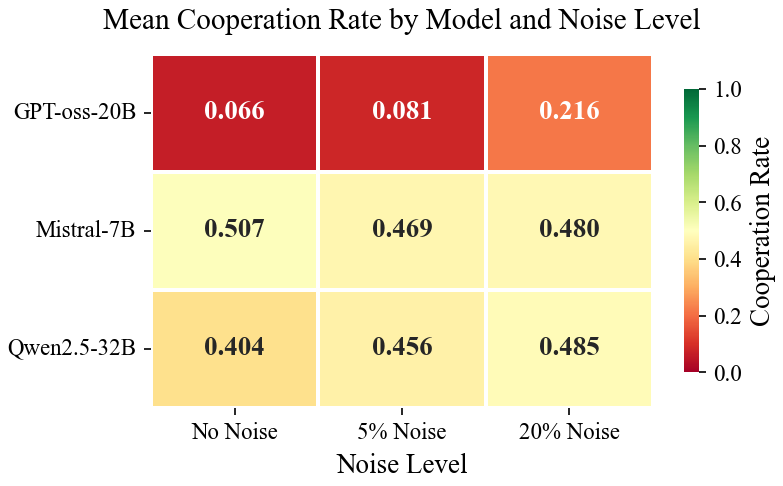

Saved: fig1_cooperation_heatmap.pdf/png


In [4]:
# ── Figure 1: Heatmap ──
pivot_mean = df.pivot_table(
    values='agent1_cooperation_rate',
    index='model',
    columns='agent1_noise_rate',
    aggfunc='mean'
).reindex(['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B'])
pivot_mean.columns = [NOISE_LABELS[c] for c in pivot_mean.columns]

fig, ax = plt.subplots(figsize=(5.5, 3.5))
sns.heatmap(
    pivot_mean, annot=True, fmt='.3f', cmap='RdYlGn',
    vmin=0, vmax=1, linewidths=1, linecolor='white',
    cbar_kws={'label': 'Cooperation Rate', 'shrink': 0.8},
    annot_kws={'fontsize': 13, 'fontweight': 'bold'},
    ax=ax
)
ax.set_xlabel('Noise Level')
ax.set_ylabel('')
ax.set_title('Mean Cooperation Rate by Model and Noise Level', fontsize=14, pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig1_cooperation_heatmap.pdf')
fig.savefig(f'{FIGURE_DIR}fig1_cooperation_heatmap.png')
plt.show()
print('Saved: fig1_cooperation_heatmap.pdf/png')

## 1.3 Figure 1b — Personality Effect by Model

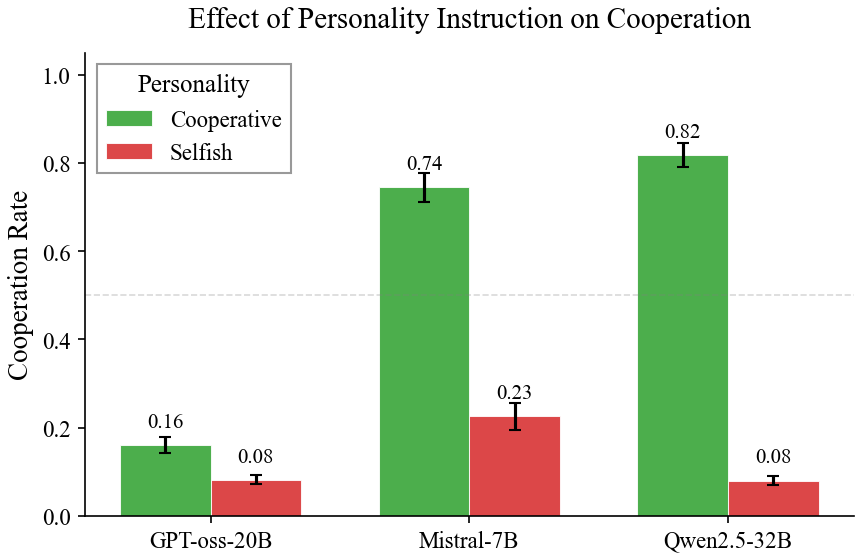

Saved: fig1b_personality_effect.pdf/png


In [5]:
# ── Figure 1b: Grouped bar — personality effect ──
pers_data = df.groupby(['model', 'personality'])['agent1_cooperation_rate'].agg(['mean', 'std', 'count']).reset_index()
pers_data['se'] = pers_data['std'] / np.sqrt(pers_data['count'])

fig, ax = plt.subplots(figsize=(6, 4))
models_order = ['GPT-oss-20B', 'Mistral-7B', 'Qwen2.5-32B']
x = np.arange(len(models_order))
width = 0.35

for i, pers in enumerate(['Cooperative', 'Selfish']):
    sub = pers_data[pers_data['personality'] == pers].set_index('model').reindex(models_order)
    color = '#2ca02c' if pers == 'Cooperative' else '#d62728'
    bars = ax.bar(
        x + (i - 0.5) * width, sub['mean'], width,
        yerr=sub['se'] * 1.96, capsize=3,
        label=pers, color=color, alpha=0.85,
        edgecolor='white', linewidth=0.5
    )
    # Add value labels
    for bar, val in zip(bars, sub['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(models_order)
ax.set_ylabel('Cooperation Rate')
ax.set_title('Effect of Personality Instruction on Cooperation', fontsize=14, pad=12)
ax.set_ylim(0, 1.05)
ax.legend(title='Personality', frameon=True, fancybox=False, edgecolor='gray')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig1b_personality_effect.pdf')
fig.savefig(f'{FIGURE_DIR}fig1b_personality_effect.png')
plt.show()
print('Saved: fig1b_personality_effect.pdf/png')

## 1.4 Statistical Tests

In [6]:
# ── Kruskal-Wallis: cooperation rate across models ──
groups = [g['agent1_cooperation_rate'].values for _, g in df.groupby('model')]
H, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis (Model effect): H = {H:.2f}, p = {p_kw:.2e}')

# Post-hoc: pairwise Mann-Whitney with Bonferroni correction
print('\nPost-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected):')
print('-' * 65)
model_names = sorted(df['model'].unique())
n_comparisons = len(list(combinations(model_names, 2)))
for m1, m2 in combinations(model_names, 2):
    g1 = df[df['model'] == m1]['agent1_cooperation_rate']
    g2 = df[df['model'] == m2]['agent1_cooperation_rate']
    U, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
    # Effect size: rank-biserial correlation
    n1, n2 = len(g1), len(g2)
    r = 1 - (2 * U) / (n1 * n2)
    p_adj = min(p * n_comparisons, 1.0)
    sig = '***' if p_adj < 0.001 else '**' if p_adj < 0.01 else '*' if p_adj < 0.05 else 'ns'
    print(f'  {m1} vs {m2}: U={U:.0f}, p_adj={p_adj:.4e}, r={r:.3f} {sig}')

# ── Personality effect: Wilcoxon rank-sum per model ──
print('\nPersonality effect (Cooperative vs Selfish) per model:')
print('-' * 65)
for model in models_order:
    coop = df[(df['model'] == model) & (df['personality'] == 'Cooperative')]['agent1_cooperation_rate']
    self_ = df[(df['model'] == model) & (df['personality'] == 'Selfish')]['agent1_cooperation_rate']
    U, p = stats.mannwhitneyu(coop, self_, alternative='two-sided')
    # Cohen's d
    cohens_d = (coop.mean() - self_.mean()) / np.sqrt((coop.std()**2 + self_.std()**2) / 2)
    print(f'  {model}: Coop={coop.mean():.3f}, Self={self_.mean():.3f}, '
          f"Cohen's d={cohens_d:.3f}, p={p:.2e}")

Kruskal-Wallis (Model effect): H = 258.11, p = 8.95e-57

Post-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected):
-----------------------------------------------------------------
  GPT-oss-20B vs Mistral-7B: U=137290, p_adj=5.6698e-54, r=0.470 ***
  GPT-oss-20B vs Qwen2.5-32B: U=165305, p_adj=1.1569e-32, r=0.362 ***
  Mistral-7B vs Qwen2.5-32B: U=273668, p_adj=1.9614e-01, r=-0.056 ns

Personality effect (Cooperative vs Selfish) per model:
-----------------------------------------------------------------
  GPT-oss-20B: Coop=0.160, Self=0.082, Cohen's d=0.560, p=3.88e-16
  Mistral-7B: Coop=0.745, Self=0.226, Cohen's d=1.678, p=1.03e-58
  Qwen2.5-32B: Coop=0.817, Self=0.080, Cohen's d=3.731, p=6.17e-106


## 1.5 Supplementary: Distribution of Cooperation Rates

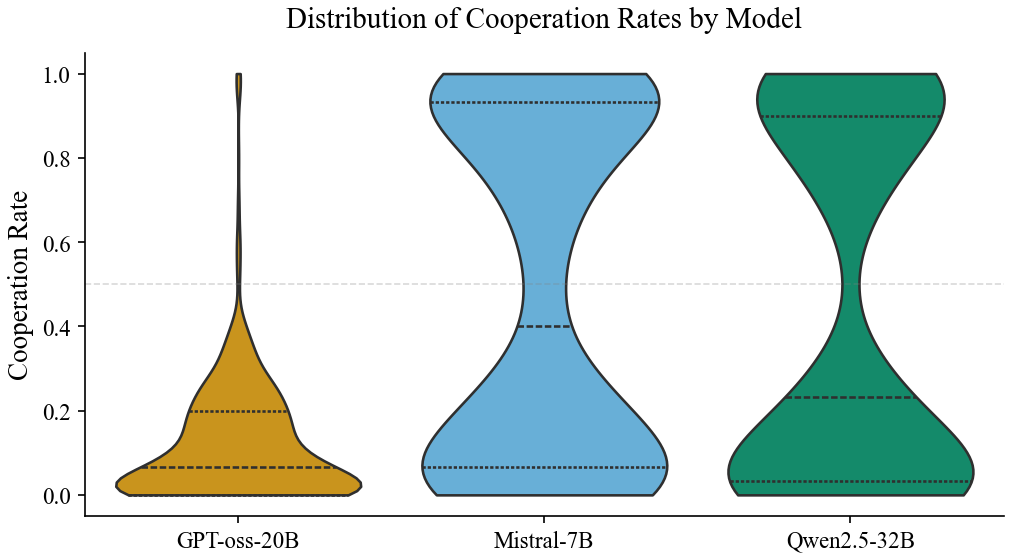

In [7]:
# ── Supplementary: Violin plot of cooperation rate distributions ──
fig, ax = plt.subplots(figsize=(7, 4))

palette = [MODEL_COLORS[k] for k in ['gpt-oss-20b', 'Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct']]
sns.violinplot(
    data=df, x='model', y='agent1_cooperation_rate',
    order=models_order, palette=palette,
    inner='quartile', cut=0, ax=ax
)
ax.set_xlabel('')
ax.set_ylabel('Cooperation Rate')
ax.set_title('Distribution of Cooperation Rates by Model', fontsize=14, pad=12)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

plt.tight_layout()
fig.savefig(f'{FIGURE_DIR}fig1_supp_violin.pdf')
fig.savefig(f'{FIGURE_DIR}fig1_supp_violin.png')
plt.show()